# Viral — 학교 단위 가입 확산

2023년 5월 가입 급증이 학교 내부 확산 패턴과 일치하는지 확인한다.

- 모집단: 직원·운영 계정을 제외한 전체 가입자
- 분석 단위: 사용자, 학교, 가입일
- 해석 한계: 초대 발신자와 가입자의 연결 정보가 없어 K-Factor와 Viral Cycle Time은 계산하지 않는다.


## 1. 유사 서비스 사례

tbh, Gas, SLAY는 학교 친구를 후보로 사용하는 익명 칭찬·투표 구조로 단기간에 성장했다. 유사 사례는 분석 가설을 세우는 배경으로만 사용한다.

- [tbh — TechCrunch](https://techcrunch.com/2017/10/16/facebook-acquires-anonymous-teen-compliment-app-TBH-will-let-it-run/)
- [Gas — TechCrunch](https://techcrunch.com/2023/10/19/discord-kills-gas-anonymous-compliments-app-bought-nine-months-ago/)
- [SLAY — TechCrunch](https://techcrunch.com/2023/01/19/german-teens-went-crazy-for-this-compliments-app-and-now-vcs-are-backing-its-next-phase/)


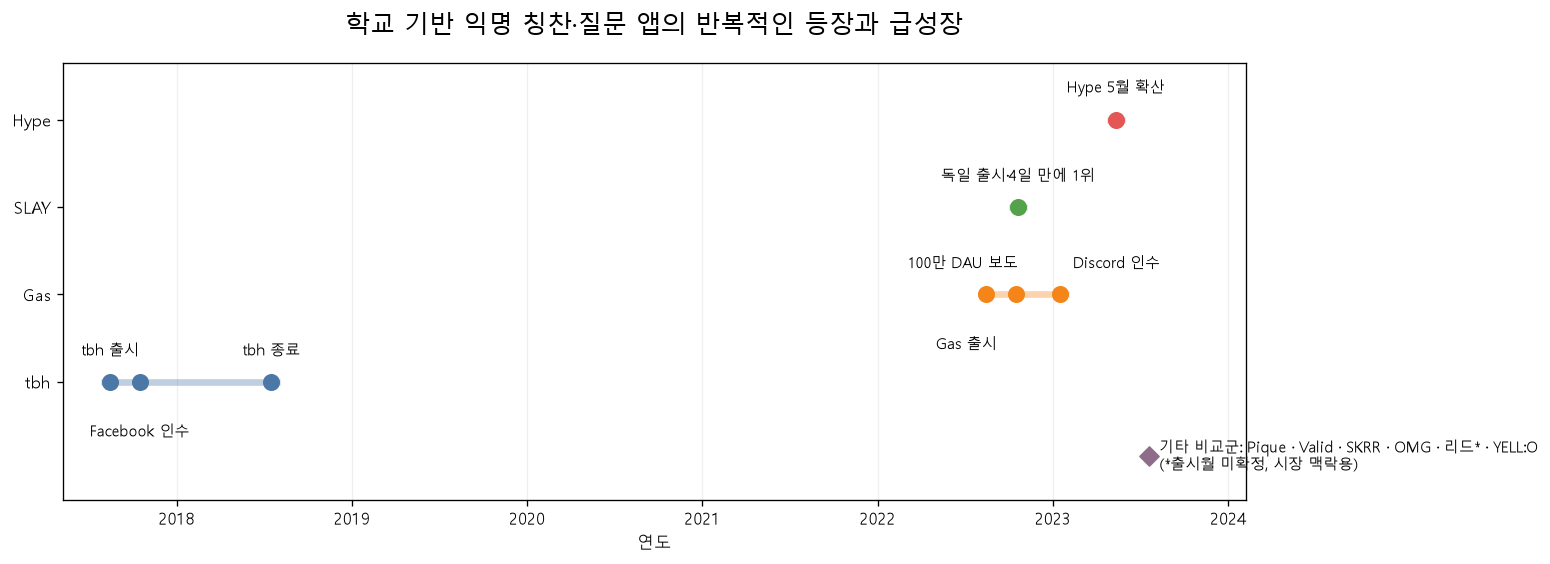

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd
import numpy as np

# Windows에서 한글이 깨지지 않도록 설정합니다.
if any(f.name == "Malgun Gothic" for f in font_manager.fontManager.ttflist):
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

timeline = pd.DataFrame([
    (2017.62, "tbh 출시", "tbh"),
    (2017.79, "Facebook 인수", "tbh"),
    (2018.54, "tbh 종료", "tbh"),
    (2022.62, "Gas 출시", "Gas"),
    (2022.79, "100만 DAU 보도", "Gas"),
    (2023.04, "Discord 인수", "Gas"),
    (2022.80, "독일 출시·4일 만에 1위", "SLAY"),
    (2023.36, "Hype 5월 확산", "Hype"),
], columns=["x", "event", "service"])

services = ["tbh", "Gas", "SLAY", "Hype"]
colors = {"tbh": "#4C78A8", "Gas": "#F58518", "SLAY": "#54A24B", "Hype": "#E45756"}

fig, ax = plt.subplots(figsize=(13, 4.8))
for y, service in enumerate(services):
    part = timeline[timeline["service"] == service]
    ax.hlines(y, part["x"].min() - 0.05, part["x"].max() + 0.05,
              color=colors[service], linewidth=4, alpha=.35)
    ax.scatter(part["x"], [y] * len(part), s=85, color=colors[service], zorder=3)
    label_offsets = {
        "tbh 출시": (0, 14), "Facebook 인수": (0, -25), "tbh 종료": (0, 14),
        "Gas 출시": (-12, -25), "100만 DAU 보도": (-32, 14), "Discord 인수": (34, 14),
        "독일 출시·4일 만에 1위": (0, 14), "Hype 5월 확산": (0, 14),
    }
    for _, row in part.iterrows():
        dx, dy = label_offsets[row["event"]]
        ax.annotate(row["event"], (row["x"], y), xytext=(dx, dy),
                    textcoords="offset points", ha="center",
                    va="bottom" if dy > 0 else "top", fontsize=9)

ax.scatter([2023.55], [-0.85], marker="D", s=65, color="#8E6C8A")
ax.text(2023.55, -0.85,
        "  기타 비교군: Pique · Valid · SKRR · OMG · 리드* · YELL:O\n  (*출시월 미확정, 시장 맥락용)",
        va="center", fontsize=9)
ax.set_yticks(range(len(services)), services)
ax.set_xlim(2017.35, 2024.1)
ax.set_ylim(-1.35, 3.65)
ax.set_xlabel("연도")
ax.set_title("학교 기반 익명 칭찬·질문 앱의 반복적인 등장과 급성장", fontsize=15, pad=18)
ax.grid(axis="x", alpha=.2)
plt.tight_layout()
plt.show()

### 해석 기준

- 유사 서비스 사례는 시장 배경이며 본 데이터의 바이럴 증거가 아니다.
- 바이럴 여부는 가입 시계열과 학교 내부 확산 지표로 판단한다.


## 2. 데이터와 식별 한계

| 데이터 | 사용 정보 | 제한 |
|---|---|---|
| `mart_user_network_snapshot` | 가입시각, 학교, 직원 여부 | 친구관계는 기준시점이 불명확한 스냅샷 |
| `mart_user_activity_daily` | 날짜별 친구 행동 수 | 초대 발신자·수신자·가입 전환 연결 없음 |

정확한 K-Factor와 Viral Cycle Time 대신 학교별 확산 속도와 가입 집중도를 사용한다.


In [2]:
from pathlib import Path
from scipy.stats import spearmanr, wilcoxon
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

DATA_DIR = Path(r"C:\Users\lucy5\Downloads")
NETWORK_PATH = DATA_DIR / "mart_user_network_snapshot.csv"
ACTIVITY_PATH = DATA_DIR / "mart_user_activity_daily(제거).csv"

assert NETWORK_PATH.exists(), f"파일이 없습니다: {NETWORK_PATH}"
assert ACTIVITY_PATH.exists(), f"파일이 없습니다: {ACTIVITY_PATH}"

print("데이터 파일 확인 완료")
print("-", NETWORK_PATH.name)
print("-", ACTIVITY_PATH.name)

데이터 파일 확인 완료
- mart_user_network_snapshot.csv
- mart_user_activity_daily(제거).csv


## 3. 분석 모집단

직원·운영 계정 4개를 제외하고 `user_created_at`을 가입시각으로 사용한다.


In [3]:
usecols = ["user_id", "user_created_at", "is_staff", "is_superuser", "school_id", "school_type"]
users_raw = pd.read_csv(NETWORK_PATH, usecols=usecols, low_memory=False)

is_staff = pd.to_numeric(users_raw["is_staff"], errors="coerce").fillna(0).eq(1)
is_super = pd.to_numeric(users_raw["is_superuser"], errors="coerce").fillna(0).eq(1)

users = users_raw.loc[~is_staff & ~is_super].copy()
users["user_created_at"] = pd.to_datetime(users["user_created_at"], errors="coerce")
users = users.dropna(subset=["user_created_at"])
users["signup_date"] = users["user_created_at"].dt.normalize()
users["signup_month"] = users["signup_date"].dt.to_period("M")
users["user_id"] = pd.to_numeric(users["user_id"], errors="coerce").astype("Int64")

scope = pd.Series({
    "전체 원본 계정": len(users_raw),
    "제외한 직원·슈퍼유저": int((is_staff | is_super).sum()),
    "분석 사용자": len(users),
    "가입일 최소": users["signup_date"].min().date(),
    "가입일 최대": users["signup_date"].max().date(),
    "학교 수": users["school_id"].nunique(),
})
display(scope.to_frame("값"))

,값
전체 원본 계정,677085
제외한 직원·슈퍼유저,4
분석 사용자,677081
가입일 최소,2023-03-29
가입일 최대,2024-05-09
학교 수,5551


### 모집단 요약

- 일반 사용자 677,081명
- 학교 5,551개


## 4. 2023년 5월 가입 급증


,결과
전체 사용자,"677,081명"
2023년 5월 가입,"635,505명"
5월 비중,93.86%
일 최대 가입일,2023-05-07
일 최대 가입자,"48,539명"


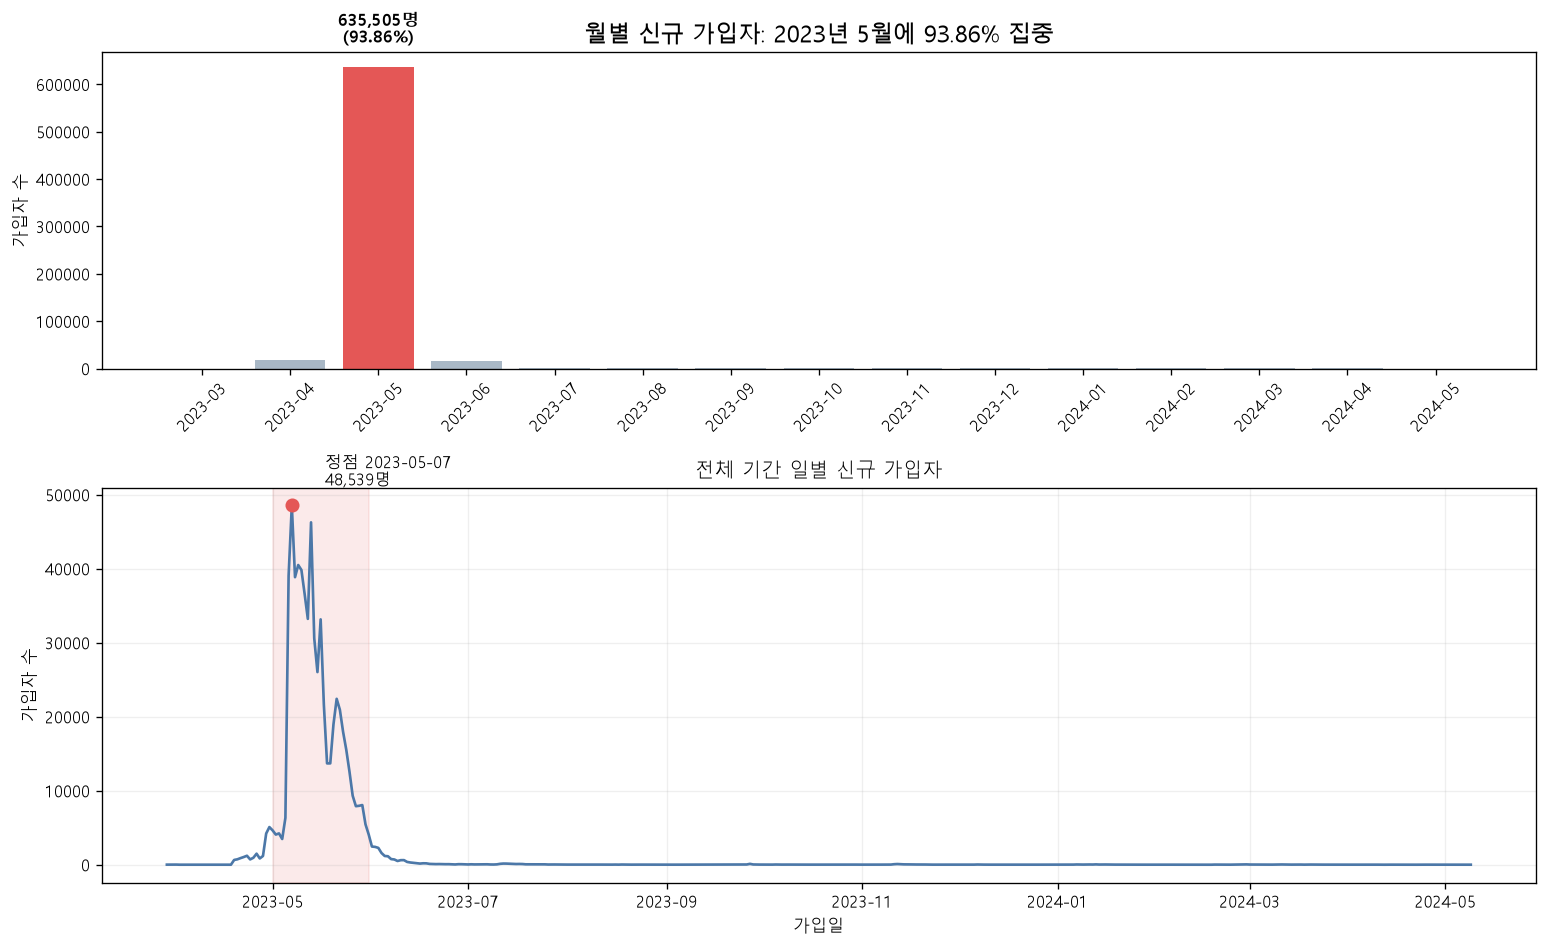

In [4]:
daily = users.groupby("signup_date").size().rename("가입자 수").sort_index()
monthly = users.groupby("signup_month").size().rename("가입자 수").sort_index()

may_count = int(monthly.loc[pd.Period("2023-05")])
may_share = may_count / len(users)
peak_date = daily.idxmax()
peak_count = int(daily.max())

summary_5m = pd.Series({
    "전체 사용자": f"{len(users):,}명",
    "2023년 5월 가입": f"{may_count:,}명",
    "5월 비중": f"{may_share:.2%}",
    "일 최대 가입일": peak_date.date(),
    "일 최대 가입자": f"{peak_count:,}명",
})
display(summary_5m.to_frame("결과"))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [1, 1.25]})

labels = [str(x) for x in monthly.index]
bar_colors = ["#E45756" if x == pd.Period("2023-05") else "#A9B8C6" for x in monthly.index]
axes[0].bar(labels, monthly.values, color=bar_colors)
axes[0].set_title("월별 신규 가입자: 2023년 5월에 93.86% 집중", fontsize=14)
axes[0].set_ylabel("가입자 수")
axes[0].tick_params(axis="x", rotation=45)
axes[0].annotate(f"{may_count:,}명\n({may_share:.2%})",
                 xy=(labels.index("2023-05"), may_count), xytext=(0, 15),
                 textcoords="offset points", ha="center", fontweight="bold")

axes[1].plot(daily.index, daily.values, color="#4C78A8", linewidth=1.6)
axes[1].axvspan(pd.Timestamp("2023-05-01"), pd.Timestamp("2023-05-31"), color="#E45756", alpha=.12)
axes[1].scatter([peak_date], [peak_count], color="#E45756", s=55, zorder=3)
axes[1].annotate(f"정점 {peak_date.date()}\n{peak_count:,}명",
                 (peak_date, peak_count), xytext=(20, 12), textcoords="offset points")
axes[1].set_title("전체 기간 일별 신규 가입자")
axes[1].set_ylabel("가입자 수")
axes[1].set_xlabel("가입일")
axes[1].grid(alpha=.2)

plt.tight_layout()
plt.show()

### 결과

- 전체 가입자의 93.86%인 635,505명이 2023년 5월에 가입했다.
- 일별 정점은 2023-05-07의 48,539명이다.


## 5. 유입 집중도와 감쇠

상위 일자 집중도와 정점 이후 감소 속도로 유입 파동의 크기와 지속기간을 확인한다.


,구간,가입자,전체 비중
0,상위 1일,"48,539",7.17%
1,상위 3일,"135,292",19.98%
2,상위 7일,"289,603",42.77%
3,상위 14일,"477,575",70.53%
4,상위 30일,"633,181",93.52%


,결과
정점의 50% 아래로 내려간 시점,정점 후 10일
정점의 10% 아래로 내려간 시점,정점 후 24일
5/14~6/15 추정 반감기,4.22일
로그-선형 감쇠 적합도 R²,0.957


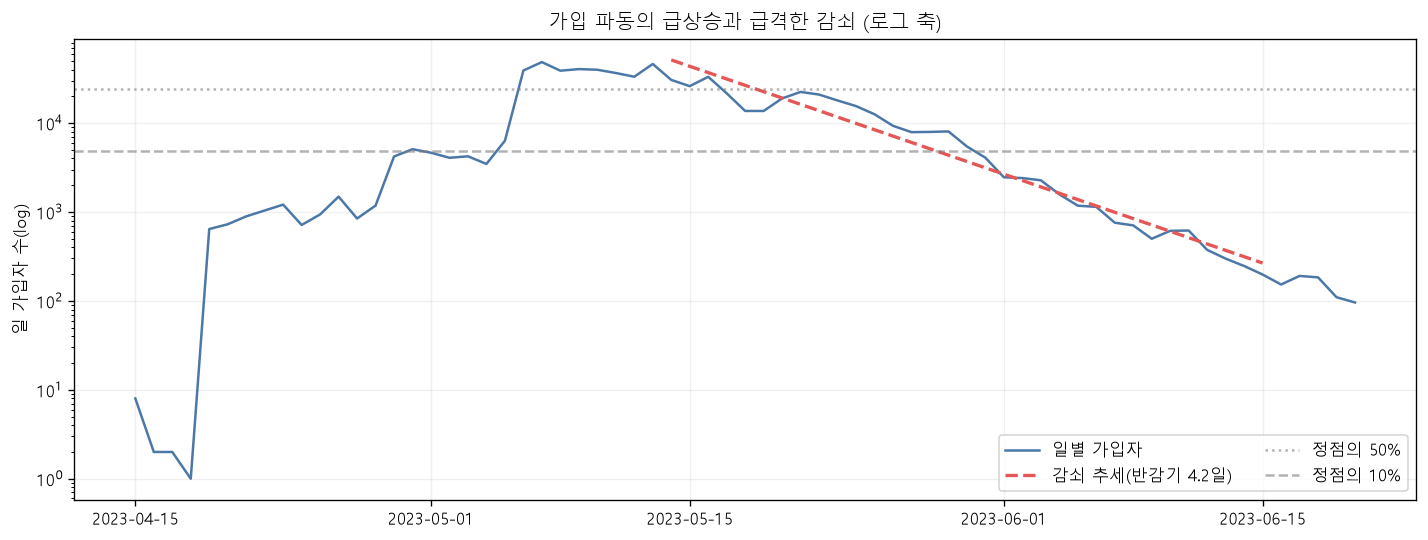

In [5]:
sorted_daily = daily.sort_values(ascending=False)
concentration = []
for k in [1, 3, 7, 14, 30]:
    n = int(sorted_daily.head(k).sum())
    concentration.append([f"상위 {k}일", n, n / daily.sum()])
concentration = pd.DataFrame(concentration, columns=["구간", "가입자", "전체 비중"])
concentration["가입자"] = concentration["가입자"].map(lambda x: f"{x:,}")
concentration["전체 비중"] = concentration["전체 비중"].map(lambda x: f"{x:.2%}")
display(concentration)

# 급락이 비교적 일정해진 5/14~6/15에 로그-선형 감쇠를 적합합니다.
decay = daily.loc["2023-05-14":"2023-06-15"]
x = np.arange(len(decay))
slope, intercept = np.polyfit(x, np.log(decay.values), 1)
fitted = np.exp(intercept + slope * x)
ss_res = np.sum((np.log(decay.values) - (intercept + slope * x)) ** 2)
ss_tot = np.sum((np.log(decay.values) - np.log(decay.values).mean()) ** 2)
r2 = 1 - ss_res / ss_tot
half_life = np.log(2) / (-slope)

after_peak = daily.loc[peak_date:]
days_to_half = int(np.argmax(after_peak.values < peak_count * .5))
days_to_tenth = int(np.argmax(after_peak.values < peak_count * .1))

display(pd.Series({
    "정점의 50% 아래로 내려간 시점": f"정점 후 {days_to_half}일",
    "정점의 10% 아래로 내려간 시점": f"정점 후 {days_to_tenth}일",
    "5/14~6/15 추정 반감기": f"{half_life:.2f}일",
    "로그-선형 감쇠 적합도 R²": f"{r2:.3f}",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(daily.loc["2023-04-15":"2023-06-20"], color="#4C78A8", label="일별 가입자")
ax.plot(decay.index, fitted, "--", color="#E45756", linewidth=2,
        label=f"감쇠 추세(반감기 {half_life:.1f}일)")
ax.axhline(peak_count * .5, color="gray", linestyle=":", alpha=.6, label="정점의 50%")
ax.axhline(peak_count * .1, color="gray", linestyle="--", alpha=.6, label="정점의 10%")
ax.set_yscale("log")
ax.set_title("가입 파동의 급상승과 급격한 감쇠 (로그 축)")
ax.set_ylabel("일 가입자 수(log)")
ax.legend(ncol=2)
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

### 결과

- 상위 7일에 전체 가입자의 42.77%, 상위 14일에 70.53%가 집중됐다.
- 정점 이후 10일 만에 절반, 24일 만에 10% 아래로 감소했다.
- 5월 14일~6월 15일 감쇠 반감기는 약 4.2일이며 적합도는 `R²≈0.957`이다.
- 짧고 강한 유입 파동이지만 원인을 입소문으로 확정할 수는 없다.


## 6. 일괄 적재 가능성 점검

생성시각 중복과 사용자 ID·가입시각의 순서를 확인한다.


In [6]:
may_users = users.loc[users["signup_month"] == pd.Period("2023-05")].copy()
same_timestamp = may_users.groupby("user_created_at").size()

ts_numeric = users["user_created_at"].astype("int64")
valid_id = users["user_id"].notna()
id_time_rho = spearmanr(users.loc[valid_id, "user_id"].astype("int64"), ts_numeric[valid_id]).statistic

batch_qa = pd.Series({
    "5월 행 수": f"{len(may_users):,}",
    "5월 고유 생성시각 수": f"{may_users['user_created_at'].nunique():,}",
    "고유 생성시각 비율": f"{may_users['user_created_at'].nunique()/len(may_users):.5%}",
    "완전히 같은 시각의 최대 계정 수": int(same_timestamp.max()),
    "user_id와 생성시각 순위상관": f"{id_time_rho:.6f}",
})
display(batch_qa.to_frame("결과"))

display(same_timestamp.sort_values(ascending=False).head(10).to_frame("같은 시각 계정 수"))

,결과
5월 행 수,"635,505"
5월 고유 생성시각 수,"635,502"
고유 생성시각 비율,99.99953%
완전히 같은 시각의 최대 계정 수,2
user_id와 생성시각 순위상관,0.999920


,같은 시각 계정 수
user_created_at,
2023-05-12 04:20:25.151806,2
2023-05-17 06:27:23.927580,2
2023-05-21 17:07:37.124684,2
2023-05-01 00:01:50.911327,1
2023-05-01 00:02:06.575151,1
2023-05-01 00:02:43.351943,1
2023-05-01 00:04:00.762047,1
2023-05-01 00:05:49.534788,1
2023-05-01 00:06:09.994563,1


### 결과

- 5월 가입자의 생성시각은 99.99953%가 고유하고 동일 시각은 최대 2명이다.
- 사용자 ID와 생성시각의 순위상관은 `ρ≈0.99992`이다.


## 7. 학교 상대일 데이터

학교별 첫 가입일을 D0로 맞춰 학교 내부 확산 속도를 비교한다.


In [7]:
school_users = users.dropna(subset=["school_id"]).copy()
school_users["school_id"] = pd.to_numeric(school_users["school_id"], errors="coerce").astype("Int64")
school_users = school_users.dropna(subset=["school_id"]).sort_values(["school_id", "user_created_at", "user_id"])

first_signup = school_users.groupby("school_id")["signup_date"].min().rename("first_signup_date")
school_users = school_users.join(first_signup, on="school_id")
school_users["day_from_first"] = (school_users["signup_date"] - school_users["first_signup_date"]).dt.days
school_users["school_rank"] = school_users.groupby("school_id").cumcount() + 1

school_size = school_users.groupby("school_id").size().rename("final_accounts")
school = pd.DataFrame(index=school_size.index).join([school_size, first_signup])

for d in [0, 1, 3, 7, 14, 30]:
    col = school_users.loc[school_users["day_from_first"] <= d].groupby("school_id").size()
    school[f"cum_d{d}"] = col.reindex(school.index, fill_value=0)

for threshold in [10, 20, 40, 100]:
    hit = school_users.loc[school_users["school_rank"] == threshold].set_index("school_id")["signup_date"]
    school[f"date_{threshold}"] = hit.reindex(school.index)
    school[f"days_to_{threshold}"] = (school[f"date_{threshold}"] - school["first_signup_date"]).dt.days

print(f"학교 수: {len(school):,}")
display(school.head())

학교 수: 5,551


,final_accounts,first_signup_date,cum_d0,cum_d1,cum_d3,cum_d7,cum_d14,cum_d30,date_10,days_to_10,date_20,days_to_20,date_40,days_to_40,date_100,days_to_100
school_id,,,,,,,,,,,,,,,,
1,93,2023-03-29,10,10,10,14,15,38,2023-03-29,0.0,2023-04-17,19.0,2023-04-29,31.0,NaT,NaN
4,235,2023-05-08,1,1,15,203,231,233,2023-05-11,3.0,2023-05-12,4.0,2023-05-12,4.0,2023-05-13,5.0
5,160,2023-05-07,11,12,15,117,158,159,2023-05-07,0.0,2023-05-13,6.0,2023-05-13,6.0,2023-05-14,7.0
6,197,2023-05-01,1,1,2,5,168,194,2023-05-11,10.0,2023-05-11,10.0,2023-05-12,11.0,2023-05-13,12.0
7,114,2023-04-23,1,1,1,2,5,106,2023-05-13,20.0,2023-05-13,20.0,2023-05-13,20.0,2023-05-18,25.0


## 8. 학교 확산의 범위와 깊이

- 범위: 신규 학교가 처음 등장한 시점
- 깊이: 학교 첫 가입 후 추가 가입이 이어진 기간


,결과
5월에 처음 등장한 학교,"4,186개"
전체 학교 중 비중,75.41%
5월 가입 중 학교 D4~D30 가입,80.08%


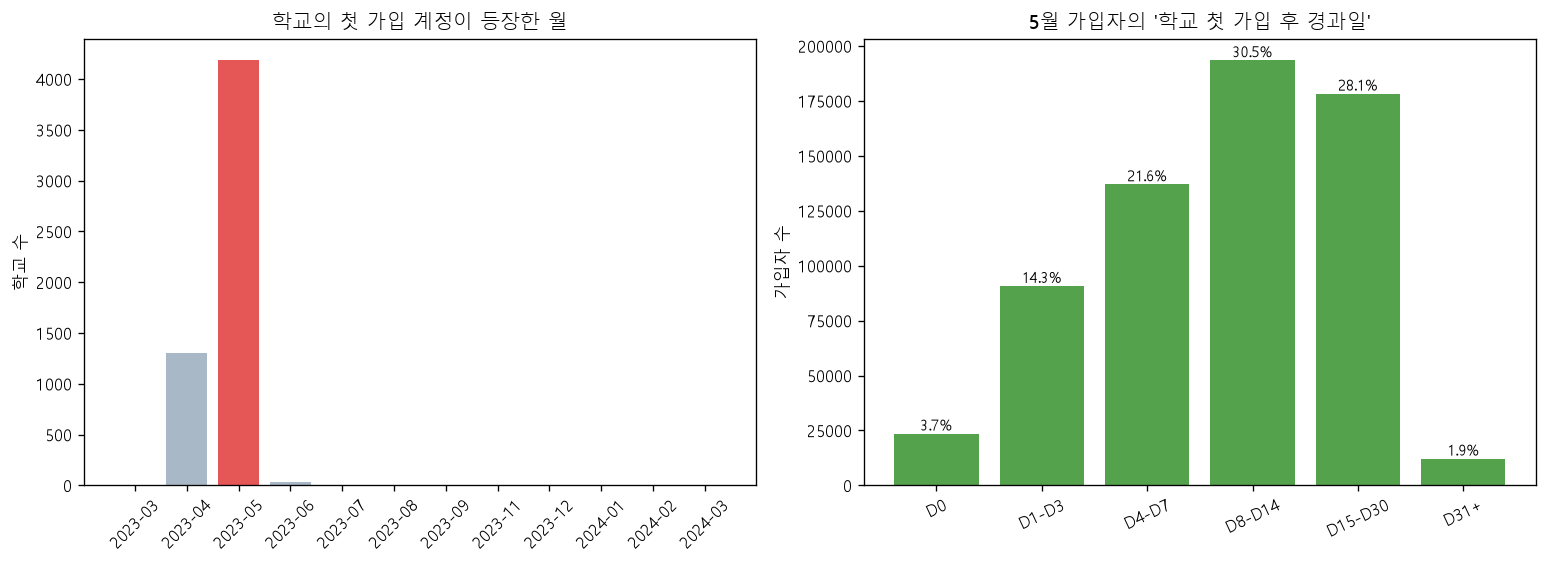

In [8]:
school_first_month = school["first_signup_date"].dt.to_period("M").value_counts().sort_index()
may_first_schools = int(school_first_month.loc[pd.Period("2023-05")])

may_school_users = school_users.loc[school_users["signup_date"].dt.to_period("M") == pd.Period("2023-05")].copy()
age_band = pd.cut(
    may_school_users["day_from_first"],
    bins=[-1, 0, 3, 7, 14, 30, np.inf],
    labels=["D0", "D1-D3", "D4-D7", "D8-D14", "D15-D30", "D31+"],
)
age_counts = age_band.value_counts(sort=False)

display(pd.Series({
    "5월에 처음 등장한 학교": f"{may_first_schools:,}개",
    "전체 학교 중 비중": f"{may_first_schools/len(school):.2%}",
    "5월 가입 중 학교 D4~D30 가입": f"{age_counts.loc[['D4-D7','D8-D14','D15-D30']].sum()/len(may_school_users):.2%}",
}).to_frame("결과"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar([str(x) for x in school_first_month.index], school_first_month.values,
            color=["#E45756" if x == pd.Period("2023-05") else "#A9B8C6" for x in school_first_month.index])
axes[0].set_title("학교의 첫 가입 계정이 등장한 월")
axes[0].set_ylabel("학교 수")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(age_counts.index.astype(str), age_counts.values, color="#54A24B")
axes[1].set_title("5월 가입자의 '학교 첫 가입 후 경과일'")
axes[1].set_ylabel("가입자 수")
axes[1].tick_params(axis="x", rotation=25)
for i, v in enumerate(age_counts.values):
    axes[1].text(i, v, f"{v/len(may_school_users):.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### 결과

- 5,551개 학교 중 4,186개(75.4%)에서 첫 계정이 5월에 등장했다.
- 5월 가입자의 80.1%는 학교 첫 가입 후 D4~D30에 가입했다.
- 신규 학교 확장과 학교 내부 가입 증가가 함께 관측됐다.


## 9. 학교 첫 가입 후 성장 속도

학교별 누적 가입자와 40명 도달 시간을 비교한다.


,median,p25,p75,p90,mean
day_from_first,,,,,
0,1.0,1.0,2.0,8.0,4.8
1,2.0,1.0,6.0,26.0,10.3
3,3.0,1.0,17.0,75.0,22.1
7,12.0,3.0,70.0,153.0,47.9
14,48.0,9.0,141.0,217.0,83.6
30,103.0,22.0,185.0,259.0,117.4


,결과
최종 40명 도달 학교,"3,897개 (70.20%)"
40명 도달 학교의 중앙 소요일,8일
도달 학교 중 D7 이내,46.96%
도달 학교 중 D14 이내,75.11%
도달 학교 중 D30 이내,97.74%


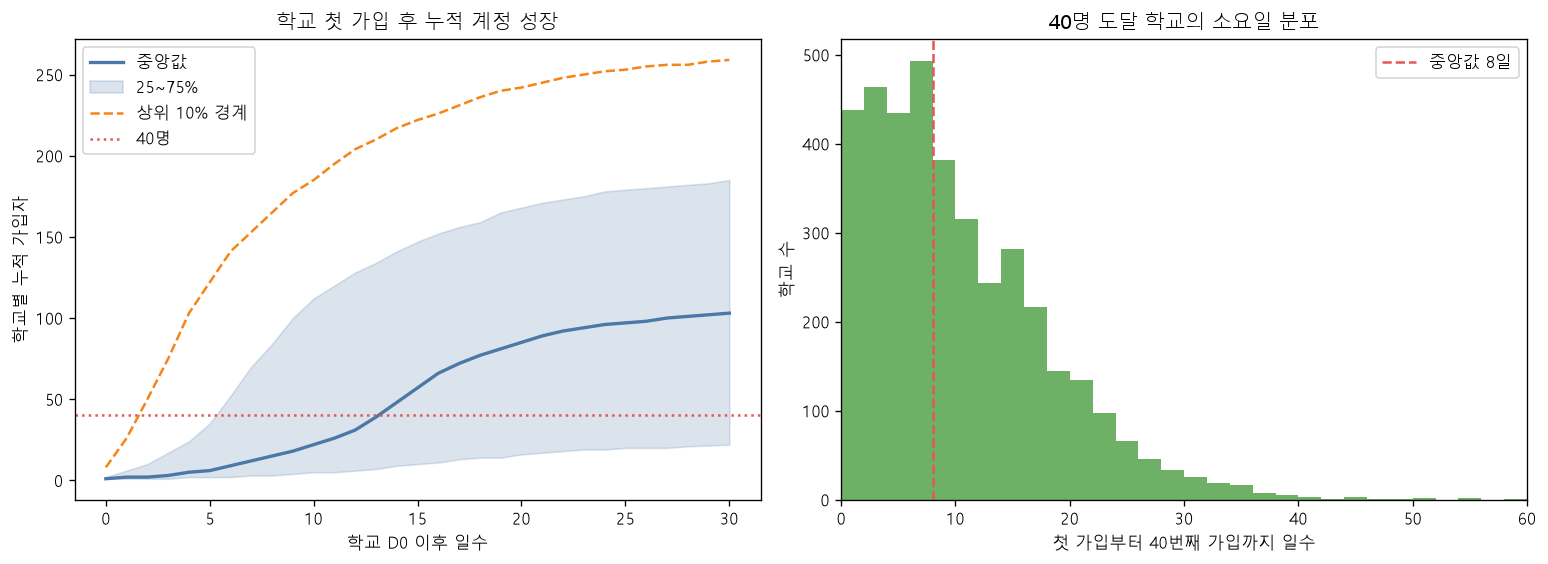

In [9]:
school_day = school_users.groupby(["school_id", "day_from_first"]).size().rename("signups").reset_index()
grid = pd.MultiIndex.from_product([school.index, range(31)], names=["school_id", "day_from_first"]).to_frame(index=False)
aligned = grid.merge(school_day, how="left", on=["school_id", "day_from_first"]).fillna({"signups": 0})
aligned["cum_signups"] = aligned.groupby("school_id")["signups"].cumsum()
aligned_summary = aligned.groupby("day_from_first")["cum_signups"].agg(
    median="median",
    p25=lambda s: s.quantile(.25),
    p75=lambda s: s.quantile(.75),
    p90=lambda s: s.quantile(.90),
    mean="mean",
)

display(aligned_summary.loc[[0, 1, 3, 7, 14, 30]].round(1))

reached40 = school["days_to_40"].notna()
threshold_summary = pd.Series({
    "최종 40명 도달 학교": f"{reached40.sum():,}개 ({reached40.mean():.2%})",
    "40명 도달 학교의 중앙 소요일": f"{school.loc[reached40, 'days_to_40'].median():.0f}일",
    "도달 학교 중 D7 이내": f"{school.loc[reached40, 'days_to_40'].le(7).mean():.2%}",
    "도달 학교 중 D14 이내": f"{school.loc[reached40, 'days_to_40'].le(14).mean():.2%}",
    "도달 학교 중 D30 이내": f"{school.loc[reached40, 'days_to_40'].le(30).mean():.2%}",
})
display(threshold_summary.to_frame("결과"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = aligned_summary.index.to_numpy(dtype=float)
axes[0].plot(x, aligned_summary["median"].to_numpy(dtype=float), label="중앙값", color="#4C78A8", linewidth=2)
axes[0].fill_between(x,
                     aligned_summary["p25"].to_numpy(dtype=float),
                     aligned_summary["p75"].to_numpy(dtype=float),
                     alpha=.2, color="#4C78A8", label="25~75%")
axes[0].plot(x, aligned_summary["p90"].to_numpy(dtype=float), "--", color="#F58518", label="상위 10% 경계")
axes[0].axhline(40, color="#E45756", linestyle=":", label="40명")
axes[0].set_title("학교 첫 가입 후 누적 계정 성장")
axes[0].set_xlabel("학교 D0 이후 일수")
axes[0].set_ylabel("학교별 누적 가입자")
axes[0].legend()

axes[1].hist(school.loc[reached40, "days_to_40"], bins=np.arange(0, 61, 2), color="#54A24B", alpha=.85)
axes[1].axvline(school.loc[reached40, "days_to_40"].median(), color="#E45756", linestyle="--",
                label=f"중앙값 {school.loc[reached40, 'days_to_40'].median():.0f}일")
axes[1].set_xlim(0, 60)
axes[1].set_title("40명 도달 학교의 소요일 분포")
axes[1].set_xlabel("첫 가입부터 40번째 가입까지 일수")
axes[1].set_ylabel("학교 수")
axes[1].legend()

plt.tight_layout()
plt.show()

### 결과

- 학교별 중앙 누적 가입자는 D0 1명, D7 12명, D14 48명, D30 103명이다.
- 3,897개 학교가 40명에 도달했으며 중앙 소요시간은 8일이다.
- 40명 도달 학교의 75.1%는 14일, 97.7%는 30일 안에 도달했다.


## 10. 전국 파동을 통제한 학교 가입 집중도

학교별 일별 가입 집중도와 전국 일별 분포에서 기대되는 집중도를 비교한다. `관측/기대 > 1`이면 전국 파동보다 학교 내부 가입이 더 집중된 것이다.


,결과
비교 학교(최종 40명 이상),"3,897개"
관측/기대 집중도 중앙값,3.08배
기대보다 더 집중된 학교 비율,99.46%
단측 Wilcoxon p-value,< 1e-300


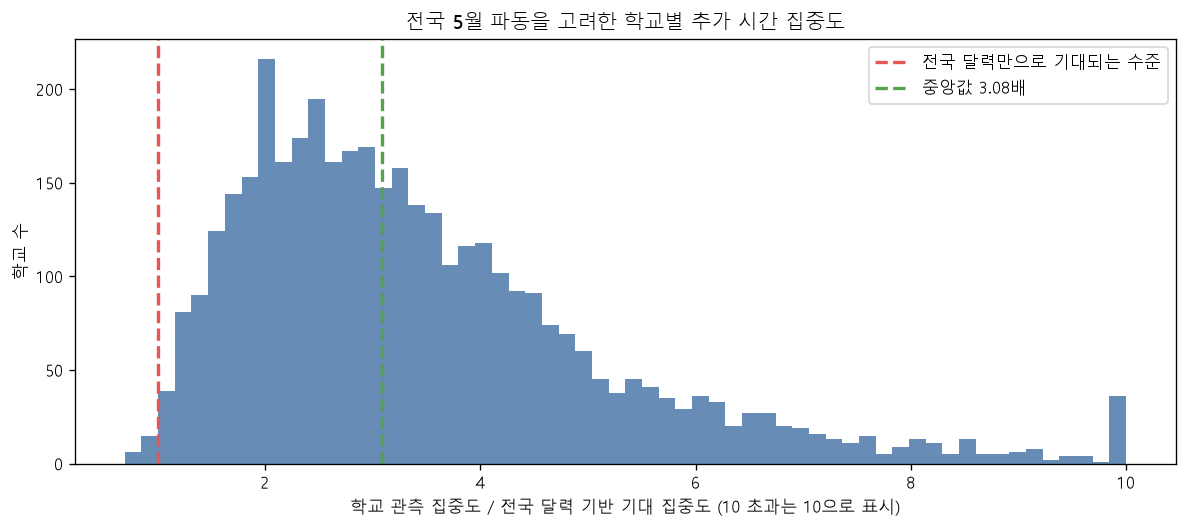

In [10]:
global_day_prob = daily / daily.sum()
global_hhi = float((global_day_prob ** 2).sum())

school_calendar_day = school_users.groupby(["school_id", "signup_date"]).size().rename("n").reset_index()
school_calendar_day = school_calendar_day.join(school_size, on="school_id")
school_calendar_day["share_sq"] = (school_calendar_day["n"] / school_calendar_day["final_accounts"]) ** 2
observed_hhi = school_calendar_day.groupby("school_id")["share_sq"].sum()

school["observed_hhi"] = observed_hhi.reindex(school.index)
# 다항분포에서 표본 크기 n을 고려한 HHI의 기대값
school["expected_hhi"] = global_hhi + (1 - global_hhi) / school["final_accounts"]
school["hhi_ratio"] = school["observed_hhi"] / school["expected_hhi"]
school["hhi_excess"] = school["observed_hhi"] - school["expected_hhi"]

hhi_sample = school.loc[school["final_accounts"] >= 40].copy()
hhi_test = wilcoxon(hhi_sample["hhi_excess"], alternative="greater")

display(pd.Series({
    "비교 학교(최종 40명 이상)": f"{len(hhi_sample):,}개",
    "관측/기대 집중도 중앙값": f"{hhi_sample['hhi_ratio'].median():.2f}배",
    "기대보다 더 집중된 학교 비율": f"{(hhi_sample['hhi_ratio'] > 1).mean():.2%}",
    "단측 Wilcoxon p-value": "< 1e-300" if hhi_test.pvalue == 0 else f"{hhi_test.pvalue:.2e}",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(hhi_sample["hhi_ratio"].clip(upper=10), bins=60, color="#4C78A8", alpha=.85)
ax.axvline(1, color="#E45756", linestyle="--", linewidth=2, label="전국 달력만으로 기대되는 수준")
ax.axvline(hhi_sample["hhi_ratio"].median(), color="#54A24B", linestyle="--", linewidth=2,
           label=f"중앙값 {hhi_sample['hhi_ratio'].median():.2f}배")
ax.set_title("전국 5월 파동을 고려한 학교별 추가 시간 집중도")
ax.set_xlabel("학교 관측 집중도 / 전국 달력 기반 기대 집중도 (10 초과는 10으로 표시)")
ax.set_ylabel("학교 수")
ax.legend()
plt.tight_layout()
plt.show()

### 결과

- 40명 이상 학교의 관측/기대 집중도 중앙값은 3.08배다.
- 분석 학교의 99.46%에서 관측 집중도가 기대값보다 높았다.
- 전국 공통 유입만으로 설명하기 어려운 학교 내부 집중이 관측됐다.


## 11. 학교 내부 가입 간격

40명 이상 학교에서 첫 14일의 연속 가입 간격을 계산한다.


,결과
학교 수,"3,807개"
학교별 중앙 가입간격의 중앙값,21.2분
25% 지점,11.5분
75% 지점,59.6분
90% 지점,7.8시간


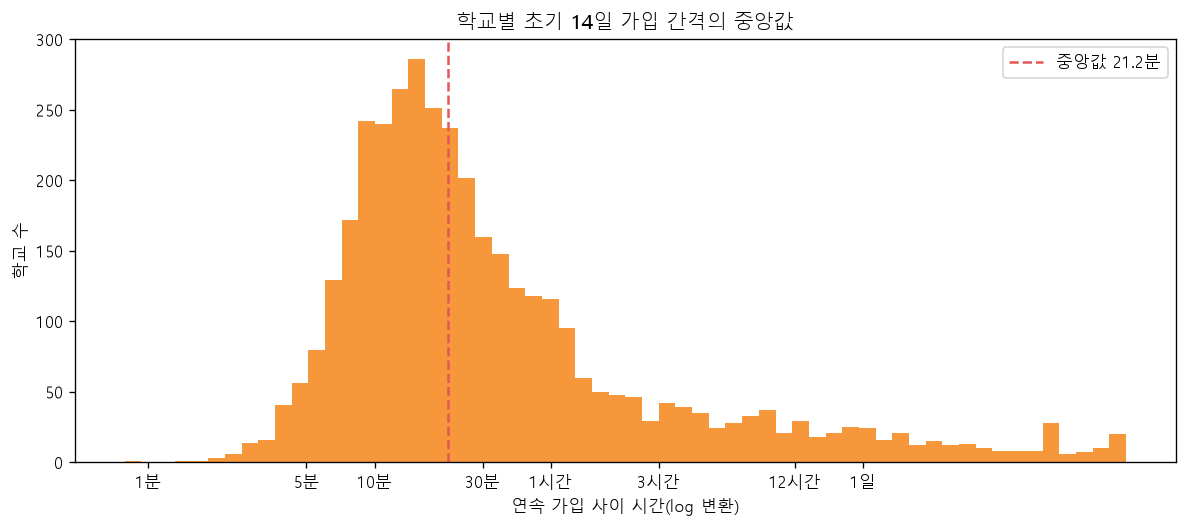

In [11]:
early14 = school_users.loc[school_users["day_from_first"] <= 14].copy()
early14["prev_signup_at"] = early14.groupby("school_id")["user_created_at"].shift()
early14["gap_minutes"] = (early14["user_created_at"] - early14["prev_signup_at"]).dt.total_seconds() / 60
school_gap = early14.groupby("school_id")["gap_minutes"].median()
gap40 = school_gap.reindex(hhi_sample.index).dropna()

display(pd.Series({
    "학교 수": f"{len(gap40):,}개",
    "학교별 중앙 가입간격의 중앙값": f"{gap40.median():.1f}분",
    "25% 지점": f"{gap40.quantile(.25):.1f}분",
    "75% 지점": f"{gap40.quantile(.75):.1f}분",
    "90% 지점": f"{gap40.quantile(.90)/60:.1f}시간",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(np.log10(gap40.clip(lower=.01)), bins=60, color="#F58518", alpha=.85)
ticks = np.log10([1, 5, 10, 30, 60, 180, 720, 1440])
ax.set_xticks(ticks, ["1분", "5분", "10분", "30분", "1시간", "3시간", "12시간", "1일"])
ax.axvline(np.log10(gap40.median()), color="#E45756", linestyle="--",
           label=f"중앙값 {gap40.median():.1f}분")
ax.set_title("학교별 초기 14일 가입 간격의 중앙값")
ax.set_xlabel("연속 가입 사이 시간(log 변환)")
ax.set_ylabel("학교 수")
ax.legend()
plt.tight_layout()
plt.show()

### 결과

학교별 중앙 가입간격의 중앙값은 약 21.2분이다.


## 12. 초기 성장과 이후 확산

D3 누적 가입과 D4~D14 추가 가입의 관계를 확인한다.


,결과
학교 수,"5,551"
D3 누적과 D4~D14 추가 가입의 Spearman ρ,0.349
p-value,5.48e-159


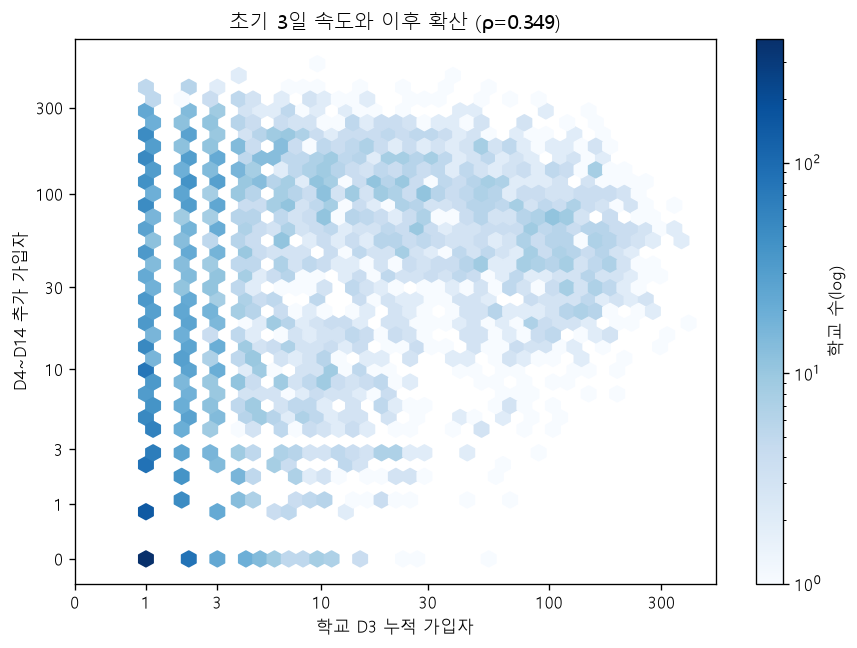

In [12]:
school["later_d4_d14"] = school["cum_d14"] - school["cum_d3"]
eligible_corr = school.loc[school["first_signup_date"] <= users["signup_date"].max() - pd.Timedelta(days=14)].copy()
momentum_rho, momentum_p = spearmanr(eligible_corr["cum_d3"], eligible_corr["later_d4_d14"])

display(pd.Series({
    "학교 수": f"{len(eligible_corr):,}",
    "D3 누적과 D4~D14 추가 가입의 Spearman ρ": f"{momentum_rho:.3f}",
    "p-value": f"{momentum_p:.2e}",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
x_plot = np.log1p(eligible_corr["cum_d3"])
y_plot = np.log1p(eligible_corr["later_d4_d14"])
hb = ax.hexbin(x_plot, y_plot, gridsize=38, bins="log", mincnt=1, cmap="Blues")
raw_ticks = np.array([0, 1, 3, 10, 30, 100, 300])
ax.set_xticks(np.log1p(raw_ticks), raw_ticks)
ax.set_yticks(np.log1p(raw_ticks), raw_ticks)
ax.set_xlabel("학교 D3 누적 가입자")
ax.set_ylabel("D4~D14 추가 가입자")
ax.set_title(f"초기 3일 속도와 이후 확산 (ρ={momentum_rho:.3f})")
fig.colorbar(hb, ax=ax, label="학교 수(log)")
plt.tight_layout()
plt.show()

In [13]:
# 심화: 5월에 처음 등장했고 D3 시점에 아직 40명 미만인 학교만 사용합니다.
# 입력은 D0, D1, D2~D3 신규 가입 수이며, 목표는 D14까지 40명 도달 여부입니다.
daily_wide = school_day.pivot(index="school_id", columns="day_from_first", values="signups").fillna(0)
model_df = pd.DataFrame(index=school.index)
model_df["first_signup_date"] = school["first_signup_date"]
model_df["d0"] = daily_wide.get(0, pd.Series(0, index=daily_wide.index)).reindex(model_df.index, fill_value=0)
model_df["d1"] = daily_wide.get(1, pd.Series(0, index=daily_wide.index)).reindex(model_df.index, fill_value=0)
model_df["d2_d3"] = daily_wide.reindex(columns=[2, 3], fill_value=0).sum(axis=1).reindex(model_df.index, fill_value=0)
model_df["cum_d3"] = school["cum_d3"]
model_df["target_d14_40"] = school["days_to_40"].le(14).astype(int)

model_df = model_df.loc[
    model_df["first_signup_date"].dt.to_period("M").eq(pd.Period("2023-05"))
    & model_df["cum_d3"].lt(40)
].copy()

X = np.log1p(model_df[["d0", "d1", "d2_d3"]])
y = model_df["target_d14_40"]
cv = StratifiedKFold(5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
pred = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

auc = roc_auc_score(y, pred)
ap = average_precision_score(y, pred)
cut = np.quantile(pred, .80)
top20_rate = y[pred >= cut].mean()
lift = top20_rate / y.mean()

display(pd.Series({
    "모델 대상 학교": f"{len(y):,}개",
    "실제 D14 40명 도달률": f"{y.mean():.2%}",
    "5-fold ROC-AUC": f"{auc:.3f}",
    "Average Precision": f"{ap:.3f}",
    "예측 상위 20% 실제 도달률": f"{top20_rate:.2%}",
    "전체 대비 lift": f"{lift:.2f}배",
}).to_frame("결과"))

model.fit(X, y)
coef = pd.Series(model[-1].coef_[0], index=["D0 가입", "D1 가입", "D2~D3 가입"], name="표준화 계수")
display(coef.sort_values(ascending=False).to_frame())

,결과
모델 대상 학교,"3,325개"
실제 D14 40명 도달률,42.50%
5-fold ROC-AUC,0.713
Average Precision,0.688
예측 상위 20% 실제 도달률,74.14%
전체 대비 lift,1.74배


,표준화 계수
D2~D3 가입,0.817046
D1 가입,0.130405
D0 가입,0.039324


### 결과

- D3 누적 가입과 D4~D14 추가 가입의 순위상관은 `ρ≈0.349`이다.
- 5월 신규 학교 모델의 D14 40명 도달 구분 성능은 `ROC-AUC≈0.713`이다.
- 예측 상위 20% 학교의 실제 도달률은 74.1%로 전체의 1.74배다.
- 예측적 연관성이며 인과효과로 해석하지 않는다.


## 13. 40명 도달 전후 가입 변화


,mean,median
relative_day,,
-7,0.86,0.0
-3,2.33,1.0
-2,3.55,2.0
-1,8.69,6.0
0,37.63,30.0
1,27.30,17.0
2,20.13,14.0
3,13.86,9.0
7,4.22,2.0


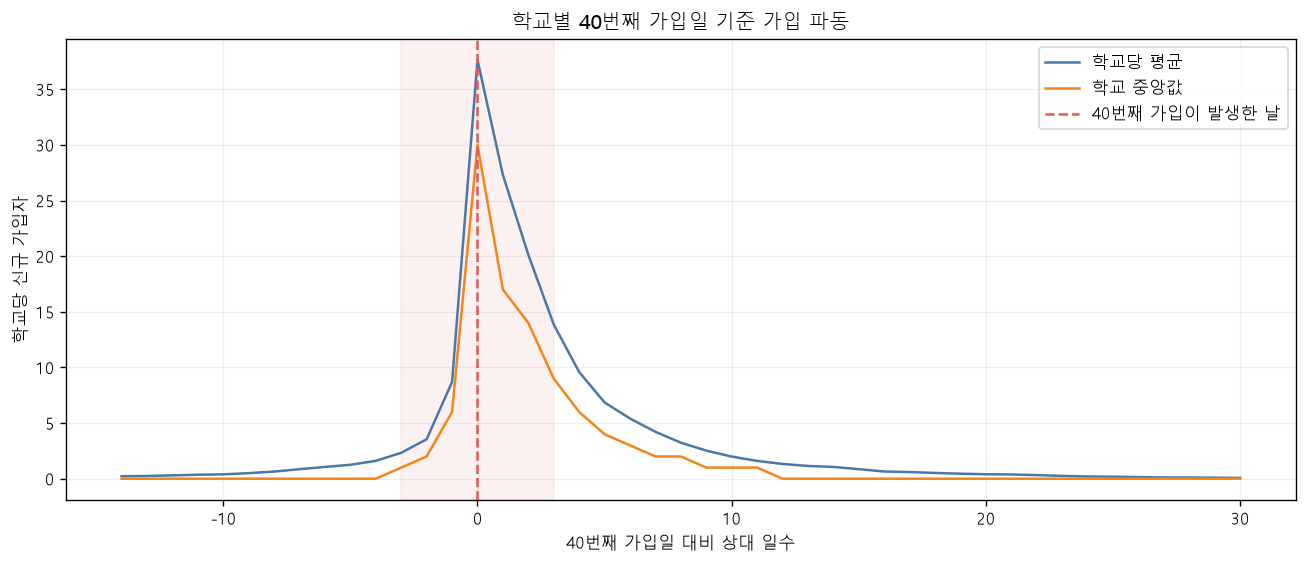

In [14]:
threshold_date = school.loc[school["date_40"].notna(), "date_40"].rename("threshold_date")
event = school_calendar_day.join(threshold_date, on="school_id")
event = event.dropna(subset=["threshold_date"])
event["relative_day"] = (event["signup_date"] - event["threshold_date"]).dt.days
event = event.loc[event["relative_day"].between(-14, 30)]

event_grid = pd.MultiIndex.from_product(
    [threshold_date.index, range(-14, 31)], names=["school_id", "relative_day"]
).to_frame(index=False)
event_full = event_grid.merge(event[["school_id", "relative_day", "n"]], how="left").fillna({"n": 0})
event_summary = event_full.groupby("relative_day")["n"].agg(mean="mean", median="median")

display(event_summary.loc[[-7, -3, -2, -1, 0, 1, 2, 3, 7, 14, 30]].round(2))

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(event_summary.index, event_summary["mean"], color="#4C78A8", label="학교당 평균")
ax.plot(event_summary.index, event_summary["median"], color="#F58518", label="학교 중앙값")
ax.axvline(0, color="#E45756", linestyle="--", label="40번째 가입이 발생한 날")
ax.axvspan(-3, 3, color="#E45756", alpha=.08)
ax.set_title("학교별 40번째 가입일 기준 가입 파동")
ax.set_xlabel("40번째 가입일 대비 상대 일수")
ax.set_ylabel("학교당 신규 가입자")
ax.legend()
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

### 결과

40명 도달 직전 가입이 증가하고 도달 후 수일간 파동이 이어졌다.


## 14. 가입과 친구 행동의 동행

`friend_action_count`는 초대가 아닌 가입 후 친구 행동 지표다.


,결과
친구 행동 총계,"17,147,175건"
5월 친구 행동 비중,93.25%
가입 당일 친구 행동 사용자,"605,582명 (89.44%)"
가입 당일 행동이 전체에서 차지하는 비중,63.75%
5월 일별 가입-친구행동 상관,ρ=0.965 (p=2.57e-18)


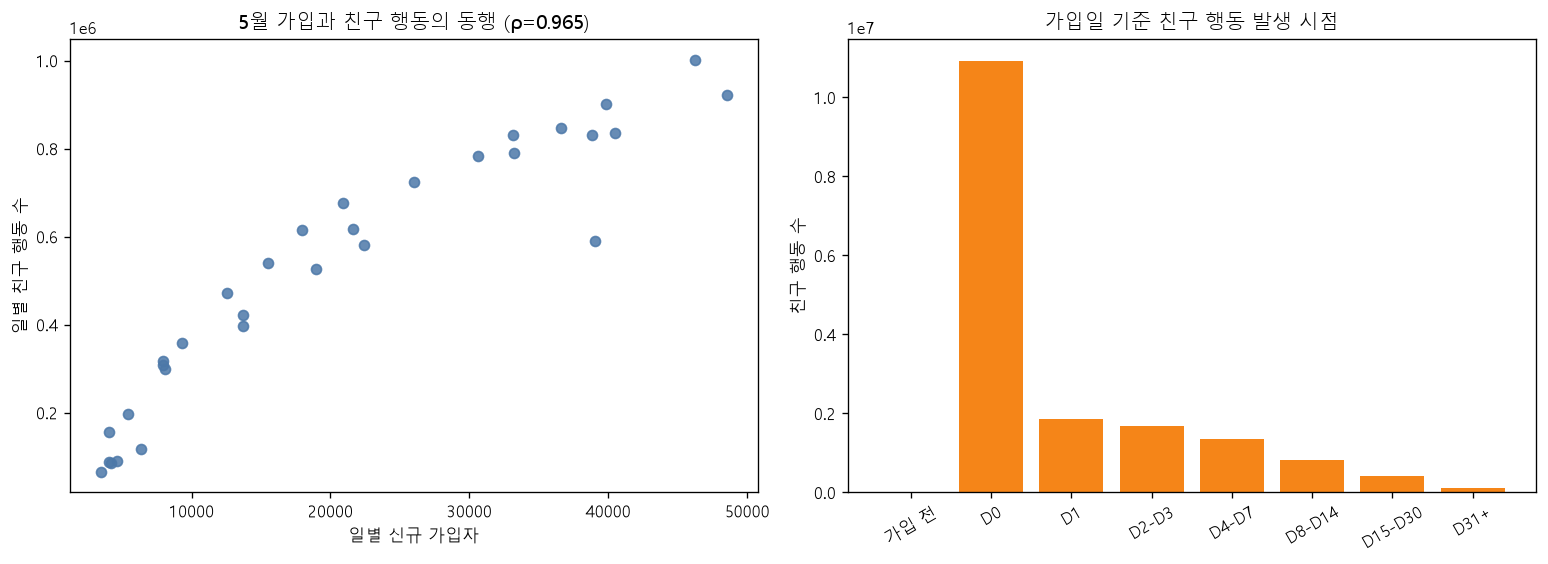

In [15]:
user_map = users[["user_id", "signup_date", "school_id"]].drop_duplicates("user_id")
positive_chunks = []

for chunk in pd.read_csv(
    ACTIVITY_PATH,
    usecols=["user_id", "activity_date", "friend_action_count"],
    chunksize=500_000,
    low_memory=False,
):
    chunk["user_id"] = pd.to_numeric(chunk["user_id"], errors="coerce").astype("Int64")
    chunk["activity_date"] = pd.to_datetime(chunk["activity_date"], errors="coerce").dt.normalize()
    chunk["friend_action_count"] = pd.to_numeric(chunk["friend_action_count"], errors="coerce").fillna(0)
    chunk = chunk.loc[chunk["friend_action_count"] > 0]
    if not chunk.empty:
        positive_chunks.append(chunk)

friend = pd.concat(positive_chunks, ignore_index=True)
friend = friend.merge(user_map, on="user_id", how="left", validate="many_to_one")
friend["days_since_signup"] = (friend["activity_date"] - friend["signup_date"]).dt.days

daily_friend = friend.groupby("activity_date")["friend_action_count"].sum().rename("친구 행동")
daily_compare = pd.concat([daily.rename("가입"), daily_friend], axis=1).fillna(0)
may_daily = daily_compare.loc["2023-05-01":"2023-05-31"]
friend_rho_may, friend_p_may = spearmanr(may_daily["가입"], may_daily["친구 행동"])

d0_friend = friend.loc[friend["days_since_signup"] == 0]
d0_users = d0_friend["user_id"].nunique()
d0_actions = d0_friend["friend_action_count"].sum()
may_actions = friend.loc[friend["activity_date"].dt.to_period("M") == pd.Period("2023-05"), "friend_action_count"].sum()

display(pd.Series({
    "친구 행동 총계": f"{friend['friend_action_count'].sum():,.0f}건",
    "5월 친구 행동 비중": f"{may_actions/friend['friend_action_count'].sum():.2%}",
    "가입 당일 친구 행동 사용자": f"{d0_users:,}명 ({d0_users/len(users):.2%})",
    "가입 당일 행동이 전체에서 차지하는 비중": f"{d0_actions/friend['friend_action_count'].sum():.2%}",
    "5월 일별 가입-친구행동 상관": f"ρ={friend_rho_may:.3f} (p={friend_p_may:.2e})",
}).to_frame("결과"))

bands = pd.cut(
    friend["days_since_signup"],
    bins=[-np.inf, -1, 0, 1, 3, 7, 14, 30, np.inf],
    labels=["가입 전", "D0", "D1", "D2-D3", "D4-D7", "D8-D14", "D15-D30", "D31+"],
)
band_actions = friend.groupby(bands, observed=False)["friend_action_count"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(may_daily["가입"], may_daily["친구 행동"], color="#4C78A8", alpha=.85)
axes[0].set_xlabel("일별 신규 가입자")
axes[0].set_ylabel("일별 친구 행동 수")
axes[0].set_title(f"5월 가입과 친구 행동의 동행 (ρ={friend_rho_may:.3f})")

axes[1].bar(band_actions.index.astype(str), band_actions.values, color="#F58518")
axes[1].set_title("가입일 기준 친구 행동 발생 시점")
axes[1].set_ylabel("친구 행동 수")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 결과

- 친구 행동 1,714만 건 중 93.25%가 5월에 발생했다.
- 친구 행동의 63.75%가 사용자 가입 당일에 발생했다.
- 5월 일별 가입자와 친구 행동의 순위상관은 `ρ≈0.965`이다.


## 15. K-Factor와 Viral Cycle Time의 식별 가능성

| 지표 | 필요한 정보 | 판정 |
|---|---|---|
| K-Factor | 초대 발신자→수신자→가입자 연결 | 계산 불가 |
| 초대 전환율 | 초대 발송·클릭·가입 연결 | 계산 불가 |
| Viral Cycle Time | 연결된 두 사용자의 가입시각 | 계산 불가 |
| 학교 가입 도착 간격 | 학교와 가입시각 | 계산 가능: 21.2분 |
| 학교 국소 집중도 | 학교와 가입일 | 계산 가능: 중앙 3.08배 |


## 16. 증거 종합


In [16]:
evidence = pd.DataFrame([
    ["시간적 폭발", "5월 635,505명·전체 93.86%, 상위 14일 70.53%", "매우 강함", "짧은 획득 파동"],
    ["빠른 감쇠", "정점 후 24일 만에 10% 미만, 추정 반감기 4.2일", "강함", "바이럴 앱의 급등락과 부합"],
    ["학교 범위 확장", "4,186개 학교가 5월에 처음 등장", "강함", "소수 학교만의 현상 아님"],
    ["학교 내부 확산", "40명 도달 학교 중앙 8일, 초기 가입간격 중앙 21.2분", "강함", "학교 안의 빠른 연쇄 패턴"],
    ["전국 파동 통제", "학교 집중도 중앙 3.08배, 99.46%가 기대 초과", "매우 강함", "전국 공통 노출만으로 설명 부족"],
    ["초기 모멘텀", "D3→D4~D14 ρ=0.349, 모델 AUC≈0.713", "보통", "초기 속도가 이후 성장과 연결"],
    ["단순 배치 반증", "5월 타임스탬프 99.99953% 고유, ID-시간 ρ≈0.99992", "보통~강함", "단순 동시 INSERT와 불일치"],
    ["친구 행동", "가입과 ρ≈0.965지만 63.75%가 D0", "보조", "초대가 아닌 온보딩 가능성"],
    ["직접 초대 연결", "발신자→수신자→가입 연결 없음", "증거 없음", "K-factor·cycle 계산 금지"],
    ["외부 공개 자료", "5월 60만·자연 확산·앱스토어 1위라는 창업자 회고", "보조", "데이터 패턴과 방향 일치"],
], columns=["검증 축", "관측 결과", "증거 강도", "해석"])
display(evidence)

,검증 축,관측 결과,증거 강도,해석
0,시간적 폭발,"5월 635,505명·전체 93.86%, 상위 14일 70.53%",매우 강함,짧은 획득 파동
1,빠른 감쇠,"정점 후 24일 만에 10% 미만, 추정 반감기 4.2일",강함,바이럴 앱의 급등락과 부합
2,학교 범위 확장,"4,186개 학교가 5월에 처음 등장",강함,소수 학교만의 현상 아님
3,학교 내부 확산,"40명 도달 학교 중앙 8일, 초기 가입간격 중앙 21.2분",강함,학교 안의 빠른 연쇄 패턴
4,전국 파동 통제,"학교 집중도 중앙 3.08배, 99.46%가 기대 초과",매우 강함,전국 공통 노출만으로 설명 부족
5,초기 모멘텀,"D3→D4~D14 ρ=0.349, 모델 AUC≈0.713",보통,초기 속도가 이후 성장과 연결
6,단순 배치 반증,"5월 타임스탬프 99.99953% 고유, ID-시간 ρ≈0.99992",보통~강함,단순 동시 INSERT와 불일치
7,친구 행동,가입과 ρ≈0.965지만 63.75%가 D0,보조,초대가 아닌 온보딩 가능성
8,직접 초대 연결,발신자→수신자→가입 연결 없음,증거 없음,K-factor·cycle 계산 금지
9,외부 공개 자료,5월 60만·자연 확산·앱스토어 1위라는 창업자 회고,보조,데이터 패턴과 방향 일치


## 17. 결론

- 2023년 5월에 전체 가입자의 93.86%가 유입됐다.
- 학교 40명 도달 중앙 소요시간은 8일이었다.
- 전국 일별 분포를 고려해도 학교 내부 가입 집중도는 기대값의 중앙 3.08배였다.
- 학교별 초기 가입 속도는 이후 성장과 연결됐다.

2023년 5월 성장은 학교 단위 바이럴 확산 패턴과 강하게 부합한다. 다만 초대 발신자와 신규 가입자의 직접 연결이 없어 개인 간 추천 전환과 K-Factor는 확인할 수 없다.
